# Phase 2 — NPR Implementation + Training on ForenSynths

This notebook starts from the Phase 1 manifests:

- `forensynths_train_manifest.csv`
- `forensynths_val_manifest.csv`
- `forensynths_test_manifest.csv` if available

It implements the core Phase 2 pipeline:

1. Load the preprocessed manifests.
2. Build PyTorch datasets and dataloaders.
3. Convert images into **Neighboring Pixel Relationship (NPR)** representations.
4. Train a lightweight CNN detector for binary real/fake classification.
5. Evaluate on validation data.
6. Save checkpoints, metrics, plots, and a zipped output folder.

Default mode is `smoke` so the notebook runs quickly first. After the first successful run, change `RUN_MODE = "full"` for proper training.

In [17]:
# =========================
# CELL 1 — Imports + Setup
# =========================
import os
import json
import random
import shutil
from pathlib import Path
from typing import Optional, Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


In [26]:
# ======================================
# CELL 2 — Configuration
# ======================================
# First run should be smoke mode to confirm that everything works.
# After it finishes successfully, change RUN_MODE to "full".
RUN_MODE = "full"   # options: "smoke", "full"

# If auto-detection fails, paste the folder that contains the manifest CSV files here.
# Example: "/kaggle/working/npr_forensynths_preprocessed"
MANUAL_MANIFEST_DIR = None

OUTPUT_DIR = Path("/kaggle/working/npr_phase2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 256
CROP_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
LR = 2e-4
WEIGHT_DECAY = 0.0

if RUN_MODE == "smoke":
    # Fast check: small balanced subset and 1 epoch.
    MAX_TRAIN_PER_LABEL = 3000
    MAX_VAL_PER_LABEL = 400
    EPOCHS = 1
else:
    # Full training: use all data.
    MAX_TRAIN_PER_LABEL = None
    MAX_VAL_PER_LABEL = None
    EPOCHS = 10

USE_AMP = torch.cuda.is_available()

print("RUN_MODE:", RUN_MODE)
print("EPOCHS:", EPOCHS)
print("BATCH_SIZE:", BATCH_SIZE)
print("OUTPUT_DIR:", OUTPUT_DIR)

RUN_MODE: full
EPOCHS: 10
BATCH_SIZE: 32
OUTPUT_DIR: /kaggle/working/npr_phase2_outputs


In [27]:
# ======================================
# CELL 3 — Find and Load Manifests
# ======================================
def find_manifest_dir(manual_dir: Optional[str] = None) -> Path:
    required = ["forensynths_train_manifest.csv", "forensynths_val_manifest.csv"]

    candidates = []
    if manual_dir:
        candidates.append(Path(manual_dir))

    candidates += [
        Path("/kaggle/working/npr_forensynths_preprocessed"),
        Path("/kaggle/input/npr-forensynths-preprocessed/npr_forensynths_preprocessed"),
        Path("/kaggle/input/npr-forensynths-preprocessed"),
        Path("/kaggle/input"),
    ]

    for base in candidates:
        if not base.exists():
            continue
        if all((base / f).exists() for f in required):
            return base

    # Controlled search only for the manifest file names.
    search_roots = [Path("/kaggle/working"), Path("/kaggle/input")]
    for root in search_roots:
        if not root.exists():
            continue
        for train_csv in root.rglob("forensynths_train_manifest.csv"):
            folder = train_csv.parent
            if all((folder / f).exists() for f in required):
                return folder

    raise FileNotFoundError(
        "Could not find Phase 1 manifest CSV files. "
        "Run the preprocessing notebook first, or set MANUAL_MANIFEST_DIR to the folder containing the CSV files."
    )

MANIFEST_DIR = find_manifest_dir(MANUAL_MANIFEST_DIR)
print("Manifest directory:", MANIFEST_DIR)

train_csv = MANIFEST_DIR / "forensynths_train_manifest.csv"
val_csv = MANIFEST_DIR / "forensynths_val_manifest.csv"
test_csv = MANIFEST_DIR / "forensynths_test_manifest.csv"

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv) if test_csv.exists() else pd.DataFrame()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
print("Columns:", train_df.columns.tolist())

required_cols = {"path", "label"}
missing = required_cols - set(train_df.columns)
if missing:
    raise ValueError(f"Missing columns in train manifest: {missing}")

Manifest directory: /kaggle/working/npr_forensynths_preprocessed
Train: (144024, 7)
Validation: (1600, 7)
Test: (0, 7)
Columns: ['path', 'label', 'label_name', 'semantic_class', 'source', 'split', 'is_valid']


In [28]:
# ======================================
# CELL 4 — Clean + Optional Balanced Subset
# ======================================
def clean_manifest(df: pd.DataFrame, name: str) -> pd.DataFrame:
    if len(df) == 0:
        return df.copy()
    out = df.copy()
    out["label"] = out["label"].astype(int)
    out = out[out["label"].isin([0, 1])].reset_index(drop=True)
    # Keep only rows whose files still exist.
    exists_mask = out["path"].apply(lambda p: Path(str(p)).exists())
    missing_count = int((~exists_mask).sum())
    if missing_count > 0:
        print(f"Warning: {name} has {missing_count} missing files; dropping them.")
    out = out[exists_mask].reset_index(drop=True)
    return out

train_df = clean_manifest(train_df, "train")
val_df = clean_manifest(val_df, "validation")
test_df = clean_manifest(test_df, "test")

def balanced_subset(df: pd.DataFrame, max_per_label: Optional[int], seed: int = SEED) -> pd.DataFrame:
    if max_per_label is None or len(df) == 0:
        return df.reset_index(drop=True)
    parts = []
    for y in [0, 1]:
        sub = df[df["label"] == y]
        n = min(max_per_label, len(sub))
        parts.append(sub.sample(n=n, random_state=seed + y))
    return pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)

train_run_df = balanced_subset(train_df, MAX_TRAIN_PER_LABEL)
val_run_df = balanced_subset(val_df, MAX_VAL_PER_LABEL)

def show_counts(df, name):
    if len(df) == 0:
        print(f"{name}: empty")
        return
    print(f"\n{name}: total={len(df)}")
    print(df["label"].map({0:"real", 1:"fake"}).value_counts().to_string())
    if "semantic_class" in df.columns:
        print("By class:")
        print(df.groupby(["semantic_class", "label"]).size().unstack(fill_value=0).to_string())

show_counts(train_run_df, "Train used in this run")
show_counts(val_run_df, "Validation used in this run")
show_counts(test_df, "Test manifest")

if len(train_run_df) == 0 or len(val_run_df) == 0:
    raise RuntimeError("Train or validation manifest is empty after cleaning. Check Phase 1 outputs.")


Train used in this run: total=144024
label
fake    72012
real    72012
By class:
label               0      1
semantic_class              
car             18003  18003
cat             18003  18003
chair           18003  18003
horse           18003  18003

Validation used in this run: total=1600
label
fake    800
real    800
By class:
label             0    1
semantic_class          
car             200  200
cat             200  200
chair           200  200
horse           200  200
Test manifest: empty


In [29]:
# ======================================
# CELL 5 — Dataset + DataLoader
# ======================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def build_transform(split: str):
    if split == "train":
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomCrop(CROP_SIZE),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.CenterCrop(CROP_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

class ManifestImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, split: str):
        self.df = df.reset_index(drop=True)
        self.transform = build_transform(split)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["path"]
        label = int(row["label"])
        try:
            img = Image.open(path).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Failed to read image: {path}\nOriginal error: {e}")
        x = self.transform(img)
        y = torch.tensor(label, dtype=torch.long)
        return x, y

train_ds = ManifestImageDataset(train_run_df, split="train")
val_ds = ManifestImageDataset(val_run_df, split="val")

def make_loader(ds, shuffle: bool):
    return DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

train_loader = make_loader(train_ds, shuffle=True)
val_loader = make_loader(val_ds, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch image shape:", tuple(xb.shape))
print("Batch label shape:", tuple(yb.shape))
print("Labels in batch:", sorted(yb.unique().tolist()))
print("Pixel range:", float(xb.min()), "to", float(xb.max()))

Batch image shape: (32, 3, 224, 224)
Batch label shape: (32,)
Labels in batch: [0, 1]
Pixel range: -2.1179039478302 to 2.640000104904175


In [30]:
# ======================================
# CELL 6 — NPR Representation
# ======================================
def npr_2x2_w1(x: torch.Tensor) -> torch.Tensor:
    """
    Neighboring Pixel Relationship using 2x2 blocks and w1 as reference.
    Input/Output shape: [B, C, H, W]

    For every 2x2 block:
        w1 = top-left pixel
        output = each pixel - w1
    """
    if x.dim() != 4:
        raise ValueError(f"Expected x shape [B,C,H,W], got {tuple(x.shape)}")

    B, C, H, W = x.shape
    if H % 2 != 0 or W % 2 != 0:
        x = x[:, :, :H - (H % 2), :W - (W % 2)]

    base = x[:, :, 0::2, 0::2]
    out = torch.empty_like(x)
    out[:, :, 0::2, 0::2] = x[:, :, 0::2, 0::2] - base
    out[:, :, 0::2, 1::2] = x[:, :, 0::2, 1::2] - base
    out[:, :, 1::2, 0::2] = x[:, :, 1::2, 0::2] - base
    out[:, :, 1::2, 1::2] = x[:, :, 1::2, 1::2] - base
    return out

with torch.no_grad():
    npr_batch = npr_2x2_w1(xb)
print("NPR batch shape:", tuple(npr_batch.shape))
print("NPR range:", float(npr_batch.min()), "to", float(npr_batch.max()))
print("Top-left pixels in 2x2 blocks should be zero-ish:", float(npr_batch[:, :, 0::2, 0::2].abs().max()))

NPR batch shape: (32, 3, 224, 224)
NPR range: -4.464285850524902 to 4.464285850524902
Top-left pixels in 2x2 blocks should be zero-ish: 0.0


In [31]:
# ======================================
# CELL 7 — Lightweight NPR CNN Model
# ======================================
class BasicBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, stride: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out = F.relu(out + identity, inplace=True)
        return out

class NPRDetector(nn.Module):
    def __init__(self, num_classes: int = 2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.layer1 = nn.Sequential(BasicBlock(32, 32), BasicBlock(32, 32))
        self.layer2 = nn.Sequential(BasicBlock(32, 64, stride=2), BasicBlock(64, 64))
        self.layer3 = nn.Sequential(BasicBlock(64, 128, stride=2), BasicBlock(128, 128))
        self.layer4 = nn.Sequential(BasicBlock(128, 256, stride=2))
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = npr_2x2_w1(x)
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)

model = NPRDetector(num_classes=2).to(DEVICE)
num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model.__class__.__name__)
print(f"Total parameters: {num_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

with torch.no_grad():
    test_logits = model(xb.to(DEVICE))
print("Output logits shape:", tuple(test_logits.shape))

NPRDetector
Total parameters: 1,614,882
Trainable parameters: 1,614,882
Output logits shape: (32, 2)


In [32]:
# ======================================
# CELL 8 — Training and Evaluation Functions
# ======================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


def evaluate(model: nn.Module, loader: DataLoader, name: str = "val") -> Dict[str, object]:
    model.eval()
    losses = []
    all_y = []
    all_prob_fake = []
    all_pred = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"Evaluating {name}", leave=False):
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(x)
                loss = criterion(logits, y)
            prob = torch.softmax(logits, dim=1)[:, 1]
            pred = torch.argmax(logits, dim=1)
            losses.append(float(loss.item()))
            all_y.extend(y.detach().cpu().numpy().tolist())
            all_prob_fake.extend(prob.detach().cpu().numpy().tolist())
            all_pred.extend(pred.detach().cpu().numpy().tolist())

    y_true = np.array(all_y)
    y_prob = np.array(all_prob_fake)
    y_pred = np.array(all_pred)

    acc = accuracy_score(y_true, y_pred)
    ap = average_precision_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else float("nan")
    try:
        auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else float("nan")
    except Exception:
        auc = float("nan")
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    return {
        "loss": float(np.mean(losses)) if losses else float("nan"),
        "accuracy": float(acc),
        "average_precision": float(ap),
        "roc_auc": float(auc),
        "confusion_matrix": cm.tolist(),
        "classification_report": classification_report(
            y_true, y_pred, labels=[0,1], target_names=["real", "fake"], zero_division=0
        ),
    }


def train_one_epoch(model: nn.Module, loader: DataLoader, epoch: int) -> Dict[str, float]:
    model.train()
    losses = []
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f"Training epoch {epoch}")
    for x, y in pbar:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        losses.append(float(loss.item()))
        pred = torch.argmax(logits.detach(), dim=1)
        correct += int((pred == y).sum().item())
        total += int(y.numel())
        pbar.set_postfix(loss=np.mean(losses), acc=correct/max(total,1))

    return {"loss": float(np.mean(losses)), "accuracy": float(correct / max(total, 1))}

/tmp/ipykernel_57/1982444792.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


In [33]:
# ======================================
# CELL 9 — Train Model
# ======================================
history = []
best_ap = -1.0
best_path = OUTPUT_DIR / "best_npr_detector.pt"
last_path = OUTPUT_DIR / "last_npr_detector.pt"

for epoch in range(1, EPOCHS + 1):
    train_metrics = train_one_epoch(model, train_loader, epoch)
    val_metrics = evaluate(model, val_loader, name="validation")

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_average_precision": val_metrics["average_precision"],
        "val_roc_auc": val_metrics["roc_auc"],
    }
    history.append(row)

    print("\nEpoch", epoch)
    print(json.dumps(row, indent=2))
    print("Confusion matrix [[real->real, real->fake], [fake->real, fake->fake]]:")
    print(np.array(val_metrics["confusion_matrix"]))

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": {
            "run_mode": RUN_MODE,
            "img_size": IMG_SIZE,
            "crop_size": CROP_SIZE,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
            "classes": {"0": "real", "1": "fake"},
            "npr": "2x2_w1",
            "architecture": "lightweight_resnet_style_cnn",
        },
        "history": history,
    }
    torch.save(checkpoint, last_path)

    current_ap = val_metrics["average_precision"]
    if current_ap > best_ap:
        best_ap = current_ap
        torch.save(checkpoint, best_path)
        print("Saved new best checkpoint:", best_path)

print("\nTraining finished.")
print("Best validation AP:", best_ap)
print("Best checkpoint:", best_path)
print("Last checkpoint:", last_path)

Training epoch 1:   0%|          | 0/4501 [00:00<?, ?it/s]

/tmp/ipykernel_57/1982444792.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Evaluating validation:   0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_57/1982444792.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):



Epoch 1
{
  "epoch": 1,
  "train_loss": 0.3348608558057706,
  "train_accuracy": 0.7894517580403266,
  "val_loss": 0.05090149208903313,
  "val_accuracy": 0.9775,
  "val_average_precision": 0.9986435593214325,
  "val_roc_auc": 0.99862734375
}
Confusion matrix [[real->real, real->fake], [fake->real, fake->fake]]:
[[791   9]
 [ 27 773]]
Saved new best checkpoint: /kaggle/working/npr_phase2_outputs/best_npr_detector.pt


...

Training epoch 10:   0%|          | 0/4501 [00:00<?, ?it/s]

/tmp/ipykernel_57/1982444792.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Evaluating validation:   0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_57/1982444792.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):



Epoch 10
{
  "epoch": 10,
  "train_loss": 0.0025674390574783597,
  "train_accuracy": 0.9991043159473421,
  "val_loss": 0.001599050834774971,
  "val_accuracy": 0.999375,
  "val_average_precision": 1.0,
  "val_roc_auc": 1.0
}
Confusion matrix [[real->real, real->fake], [fake->real, fake->fake]]:
[[799   1]
 [  0 800]]

Training finished.
Best validation AP: 1.0
Best checkpoint: /kaggle/working/npr_phase2_outputs/best_npr_detector.pt
Last checkpoint: /kaggle/working/npr_phase2_outputs/last_npr_detector.pt


Saved: /kaggle/working/npr_phase2_outputs/training_history.csv


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_average_precision,val_roc_auc
0,1,0.334861,0.789452,0.050901,0.977500,0.998644,0.998627
1,2,0.029092,0.989217,0.027593,0.987500,0.999895,0.999895
2,3,0.015267,0.994584,0.005637,0.997500,0.999989,0.999989
3,4,0.010002,0.996528,0.004876,0.999375,0.999995,0.999995
4,5,0.007151,0.997507,0.011542,0.996875,0.999981,0.999981
5,6,0.005496,0.998153,0.020474,0.994375,0.999757,0.999744
6,7,0.004377,0.998521,0.001888,0.998750,0.999998,0.999998
7,8,0.003095,0.999090,0.005552,0.998125,0.999984,0.999984
8,9,0.003055,0.999077,0.001517,0.999375,1.000000,1.000000
9,10,0.002567,0.999104,0.001599,0.999375,1.000000,1.000000


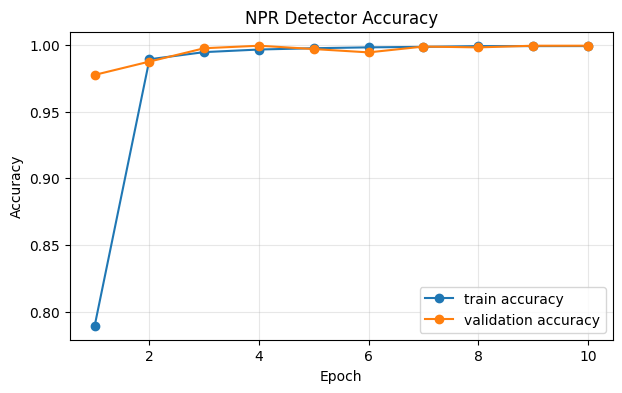

Saved: /kaggle/working/npr_phase2_outputs/accuracy_curve.png


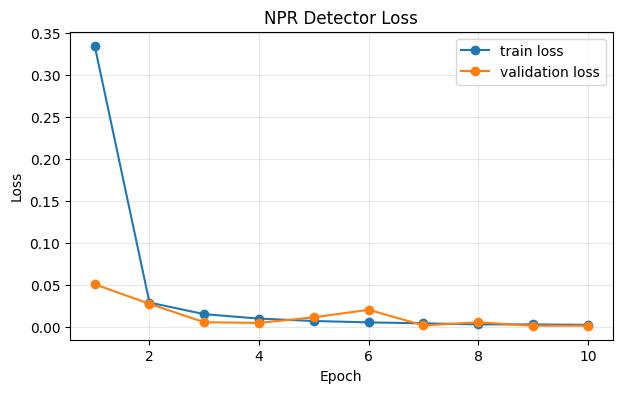

Saved: /kaggle/working/npr_phase2_outputs/loss_curve.png


In [34]:
# ======================================
# CELL 10 — Save Metrics and Plots
# ======================================
history_df = pd.DataFrame(history)
history_csv = OUTPUT_DIR / "training_history.csv"
history_df.to_csv(history_csv, index=False)
print("Saved:", history_csv)

display(history_df)

# Accuracy curve
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_accuracy"], marker="o", label="train accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("NPR Detector Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
acc_plot = OUTPUT_DIR / "accuracy_curve.png"
plt.savefig(acc_plot, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", acc_plot)

# Loss curve
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NPR Detector Loss")
plt.grid(True, alpha=0.3)
plt.legend()
loss_plot = OUTPUT_DIR / "loss_curve.png"
plt.savefig(loss_plot, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", loss_plot)

In [35]:
# ======================================
# CELL 11 — Final Validation Report
# ======================================
# Load best model before final report.
ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
final_val = evaluate(model, val_loader, name="final validation")

print("Final validation metrics:")
print("Loss:", final_val["loss"])
print("Accuracy:", final_val["accuracy"])
print("Average Precision:", final_val["average_precision"])
print("ROC-AUC:", final_val["roc_auc"])
print("\nConfusion matrix [[real->real, real->fake], [fake->real, fake->fake]]:")
print(np.array(final_val["confusion_matrix"]))
print("\nClassification report:")
print(final_val["classification_report"])

final_json = OUTPUT_DIR / "final_validation_metrics.json"
with open(final_json, "w", encoding="utf-8") as f:
    json.dump(final_val, f, indent=2)
print("Saved:", final_json)

Evaluating final validation:   0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_57/1982444792.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Final validation metrics:
Loss: 0.001517125368118286
Accuracy: 0.999375
Average Precision: 1.0
ROC-AUC: 1.0

Confusion matrix [[real->real, real->fake], [fake->real, fake->fake]]:
[[800   0]
 [  1 799]]

Classification report:
              precision    recall  f1-score   support

        real       1.00      1.00      1.00       800
        fake       1.00      1.00      1.00       800

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600

Saved: /kaggle/working/npr_phase2_outputs/final_validation_metrics.json


In [36]:
# ======================================
# CELL 12 — Optional Test Evaluation
# ======================================
if len(test_df) == 0:
    print("Test manifest is empty, so Phase 2 will stop at validation.")
    print("This is normal for your current run because your collected test manifest has 0 labelled images.")
else:
    test_ds = ManifestImageDataset(test_df, split="test")
    test_loader = make_loader(test_ds, shuffle=False)
    test_metrics = evaluate(model, test_loader, name="test")
    print("Test metrics:")
    print(json.dumps({k: v for k, v in test_metrics.items() if k != "classification_report"}, indent=2))
    print(test_metrics["classification_report"])
    test_json = OUTPUT_DIR / "test_metrics.json"
    with open(test_json, "w", encoding="utf-8") as f:
        json.dump(test_metrics, f, indent=2)
    print("Saved:", test_json)

Test manifest is empty, so Phase 2 will stop at validation.
This is normal for your current run because your collected test manifest has 0 labelled images.


In [37]:
# ======================================
# CELL 13 — Save Run Config + ZIP Outputs
# ======================================
run_config = {
    "phase": "Phase 2 - NPR implementation and training",
    "run_mode": RUN_MODE,
    "manifest_dir": str(MANIFEST_DIR),
    "train_samples_available": int(len(train_df)),
    "val_samples_available": int(len(val_df)),
    "test_samples_available": int(len(test_df)),
    "train_samples_used": int(len(train_run_df)),
    "val_samples_used": int(len(val_run_df)),
    "image_size": IMG_SIZE,
    "crop_size": CROP_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "lr": LR,
    "optimizer": "Adam",
    "loss": "CrossEntropyLoss",
    "npr_variant": "2x2_w1",
    "output_dir": str(OUTPUT_DIR),
}

config_path = OUTPUT_DIR / "phase2_run_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=2)
print("Saved:", config_path)

zip_base = "/kaggle/working/npr_phase2_outputs"
zip_path = shutil.make_archive(zip_base, "zip", OUTPUT_DIR)
print("Created ZIP:", zip_path)
print("Main files to submit/share:")
print("-", best_path)
print("-", history_csv)
print("-", final_json)
print("-", zip_path)

Saved: /kaggle/working/npr_phase2_outputs/phase2_run_config.json
Created ZIP: /kaggle/working/npr_phase2_outputs.zip
Main files to submit/share:
- /kaggle/working/npr_phase2_outputs/best_npr_detector.pt
- /kaggle/working/npr_phase2_outputs/training_history.csv
- /kaggle/working/npr_phase2_outputs/final_validation_metrics.json
- /kaggle/working/npr_phase2_outputs.zip


### phase3

Cell 1 — Imports and setup

In [38]:
# ======================================
# CELL 1 — Imports + Setup
# ======================================

import os
import json
import random
import shutil
from pathlib import Path
from typing import Optional, List, Tuple, Dict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("CUDA available:", torch.cuda.is_available())

Device: cuda
CUDA available: True


Cell 2 — Configuration

In [39]:
# ======================================
# CELL 2 — Configuration
# ======================================

DATA_ROOT = Path("/kaggle/input/datasets/chandlertimm/forensynths/Wang_CVPR2020")
TEST_DIR = DATA_ROOT / "testing"

PHASE2_DIR = Path("/kaggle/working/npr_phase2_outputs")
CKPT_PATH = PHASE2_DIR / "best_npr_detector.pt"

OUTPUT_DIR = Path("/kaggle/working/npr_phase3_evaluation_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 256
CROP_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# First run: keep it small and safe
# Example: ["biggan"]
# Later: None means evaluate all labelled testing sources found
SELECTED_TEST_SOURCES = None

# First run: 1000 or 2000 is safer.
# Final run: set to None to evaluate all available images.
MAX_IMAGES_PER_LABEL_PER_SOURCE = None

print("Data root:", DATA_ROOT)
print("Testing dir:", TEST_DIR)
print("Checkpoint:", CKPT_PATH)
print("Output dir:", OUTPUT_DIR)

Data root: /kaggle/input/datasets/chandlertimm/forensynths/Wang_CVPR2020
Testing dir: /kaggle/input/datasets/chandlertimm/forensynths/Wang_CVPR2020/testing
Checkpoint: /kaggle/working/npr_phase2_outputs/best_npr_detector.pt
Output dir: /kaggle/working/npr_phase3_evaluation_outputs


In [40]:
# ======================================
# CELL 3 — Check Dataset + Checkpoint
# ======================================

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT}")

if not TEST_DIR.exists():
    raise FileNotFoundError(f"Testing folder not found: {TEST_DIR}")

if not CKPT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CKPT_PATH}\n"
        "Make sure Phase 2 finished in this Kaggle session, or upload/copy best_npr_detector.pt."
    )

available_sources = sorted([p.name for p in TEST_DIR.iterdir() if p.is_dir()])

print("Available testing sources:")
for s in available_sources:
    print("-", s)

if SELECTED_TEST_SOURCES is not None:
    missing = [s for s in SELECTED_TEST_SOURCES if s not in available_sources]
    if missing:
        raise ValueError(f"These selected sources were not found: {missing}")

print("\nSelected sources:", SELECTED_TEST_SOURCES if SELECTED_TEST_SOURCES is not None else "ALL")

Available testing sources:
- biggan
- crn
- cyclegan
- deepfake
- gaugan
- imle
- progan
- san
- seeingdark
- stargan
- stylegan
- stylegan2
- whichfaceisreal

Selected sources: ALL


In [41]:
# ======================================
# CELL 4 — Build Test Manifest
# ======================================

REAL_TOKENS = {"0_real", "real", "0", "real_images"}
FAKE_TOKENS = {"1_fake", "fake", "1", "fake_images", "synthetic"}

def normalise_name(name: str) -> str:
    return name.lower().replace("-", "_").replace(" ", "_")

def label_name(label: int) -> str:
    return "real" if label == 0 else "fake"

def label_from_dir_name(name: str) -> Optional[int]:
    clean = normalise_name(name)
    if clean in REAL_TOKENS or clean.startswith("0_real"):
        return 0
    if clean in FAKE_TOKENS or clean.startswith("1_fake"):
        return 1
    if "real" in clean and "unreal" not in clean:
        return 0
    if "fake" in clean or "synthetic" in clean:
        return 1
    return None

def iter_image_paths_fast(folder: Path, max_images: Optional[int] = None):
    count = 0
    if not folder.exists():
        return
    for root, dirs, files in os.walk(folder):
        dirs.sort()
        files.sort()
        for fname in files:
            if Path(fname).suffix.lower() in IMG_EXTENSIONS:
                yield Path(root) / fname
                count += 1
                if max_images is not None and count >= max_images:
                    return

def find_label_dirs(source_folder: Path) -> List[Tuple[Path, int]]:
    """
    Finds folders named like 0_real, 1_fake, real, fake.
    Works even if they are nested under class folders.
    """
    found = []

    for root, dirs, files in os.walk(source_folder):
        root_path = Path(root)

        try:
            depth = len(root_path.relative_to(source_folder).parts)
        except Exception:
            depth = 0

        # Do not search too deep to avoid very slow scans
        if depth > 5:
            dirs[:] = []
            continue

        for d in dirs:
            y = label_from_dir_name(d)
            if y is not None:
                found.append((root_path / d, y))

    # Remove duplicates
    unique = []
    seen = set()
    for p, y in found:
        key = str(p)
        if key not in seen:
            unique.append((p, y))
            seen.add(key)

    return unique

def build_source_manifest(source_name: str) -> pd.DataFrame:
    source_folder = TEST_DIR / source_name
    label_dirs = find_label_dirs(source_folder)

    rows = []

    if len(label_dirs) == 0:
        print(f"WARNING: No labelled real/fake folders found inside testing/{source_name}")
        return pd.DataFrame(columns=["path", "label", "label_name", "source", "semantic_class", "split"])

    for label_dir, y in label_dirs:
        try:
            rel_parent = label_dir.parent.relative_to(source_folder)
            semantic_class = rel_parent.parts[-1] if len(rel_parent.parts) > 0 else "test"
        except Exception:
            semantic_class = "test"

        desc = f"testing/{source_name}/{semantic_class}/{label_name(y)}"
        for p in tqdm(
            iter_image_paths_fast(label_dir, MAX_IMAGES_PER_LABEL_PER_SOURCE),
            desc=desc,
            leave=False
        ):
            rows.append({
                "path": str(p),
                "label": int(y),
                "label_name": label_name(int(y)),
                "source": source_name,
                "semantic_class": semantic_class,
                "split": "testing"
            })

    return pd.DataFrame(rows)

sources_to_scan = SELECTED_TEST_SOURCES if SELECTED_TEST_SOURCES is not None else available_sources

frames = []
for src in sources_to_scan:
    df_src = build_source_manifest(src)
    print(f"testing/{src}: {len(df_src)} labelled images")
    if len(df_src) > 0:
        frames.append(df_src)

if len(frames) == 0:
    raise RuntimeError(
        "No labelled test images found. Check the folder structure under testing/. "
        "There must be folders like 0_real/1_fake or real/fake."
    )

test_df = pd.concat(frames, ignore_index=True)
test_df = test_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print("\nFinal test manifest shape:", test_df.shape)
print("\nLabel counts:")
print(test_df["label_name"].value_counts())

print("\nCounts by source and label:")
display(test_df.groupby(["source", "label_name"]).size().unstack(fill_value=0))

testing/biggan/test/fake: 0it [00:00, ?it/s]

testing/biggan/test/real: 0it [00:00, ?it/s]

testing/biggan: 4000 labelled images


testing/crn/test/fake: 0it [00:00, ?it/s]

testing/crn/test/real: 0it [00:00, ?it/s]

...

testing/stylegan2: 15976 labelled images


testing/whichfaceisreal/test/fake: 0it [00:00, ?it/s]

testing/whichfaceisreal/test/real: 0it [00:00, ?it/s]

testing/whichfaceisreal: 2000 labelled images

Final test manifest shape: (90329, 6)

Label counts:
label_name
real    45169
fake    45160
Name: count, dtype: int64

Counts by source and label:


label_name,fake,real
source,,
biggan,2000,2000
crn,6382,6382
cyclegan,1321,1321
deepfake,2698,2707
gaugan,5000,5000
imle,6382,6382
progan,4000,4000
san,219,219
seeingdark,180,180


In [42]:
# ======================================
# CELL 5 — Save Test Manifest
# ======================================

test_manifest_path = OUTPUT_DIR / "phase3_test_manifest.csv"
test_df.to_csv(test_manifest_path, index=False)

summary_df = (
    test_df.groupby(["source", "semantic_class", "label_name"])
    .size()
    .reset_index(name="count")
)

summary_path = OUTPUT_DIR / "phase3_test_manifest_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved test manifest:", test_manifest_path)
print("Saved summary:", summary_path)

display(summary_df.head(30))

Saved test manifest: /kaggle/working/npr_phase3_evaluation_outputs/phase3_test_manifest.csv
Saved summary: /kaggle/working/npr_phase3_evaluation_outputs/phase3_test_manifest_summary.csv


,source,semantic_class,label_name,count
0,biggan,test,fake,2000
1,biggan,test,real,2000
2,crn,test,fake,6382
3,crn,test,real,6382
4,cyclegan,apple,fake,248
5,cyclegan,apple,real,266
6,cyclegan,horse,fake,140
7,cyclegan,horse,real,120
8,cyclegan,orange,fake,266
9,cyclegan,orange,real,248


In [43]:
# ======================================
# CELL 6 — Dataset + DataLoader
# ======================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(CROP_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class TestManifestDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True).copy()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        x = test_transform(img)
        y = torch.tensor(int(row["label"]), dtype=torch.long)

        return {
            "image": x,
            "label": y,
            "path": row["path"],
            "source": row["source"],
            "semantic_class": row["semantic_class"],
            "label_name": row["label_name"],
        }

def collate_batch(batch):
    images = torch.stack([item["image"] for item in batch])
    labels = torch.stack([item["label"] for item in batch])

    return {
        "image": images,
        "label": labels,
        "path": [item["path"] for item in batch],
        "source": [item["source"] for item in batch],
        "semantic_class": [item["semantic_class"] for item in batch],
        "label_name": [item["label_name"] for item in batch],
    }

test_dataset = TestManifestDataset(test_df)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
    collate_fn=collate_batch,
)

print("Test images:", len(test_dataset))
print("Test batches:", len(test_loader))

batch = next(iter(test_loader))
print("Batch image shape:", tuple(batch["image"].shape))
print("Batch label shape:", tuple(batch["label"].shape))
print("Labels in batch:", sorted(batch["label"].unique().tolist()))

Test images: 90329
Test batches: 2823
Batch image shape: (32, 3, 224, 224)
Batch label shape: (32,)
Labels in batch: [0, 1]


In [44]:
# ======================================
# CELL 7 — NPRDetector Architecture
# ======================================

def npr_2x2_w1(x: torch.Tensor) -> torch.Tensor:
    """
    NPR 2x2 w1 version.
    Input shape: [B, C, H, W]
    Top-left pixel in every 2x2 block is used as reference.
    """
    if x.ndim != 4:
        raise ValueError("Expected input shape [B, C, H, W]")

    B, C, H, W = x.shape
    H_even = H - (H % 2)
    W_even = W - (W % 2)

    x = x[:, :, :H_even, :W_even]
    out = torch.zeros_like(x)

    ref = x[:, :, 0::2, 0::2]

    out[:, :, 0::2, 0::2] = x[:, :, 0::2, 0::2] - ref
    out[:, :, 0::2, 1::2] = x[:, :, 0::2, 1::2] - ref
    out[:, :, 1::2, 0::2] = x[:, :, 1::2, 0::2] - ref
    out[:, :, 1::2, 1::2] = x[:, :, 1::2, 1::2] - ref

    return out

class BasicBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, stride: int = 1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_ch, out_ch,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_ch)

        self.conv2 = nn.Conv2d(
            out_ch, out_ch,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_ch)

        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out = F.relu(out + identity, inplace=True)

        return out

class NPRDetector(nn.Module):
    def __init__(self, num_classes: int = 2):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        self.layer1 = nn.Sequential(
            BasicBlock(32, 32),
            BasicBlock(32, 32)
        )

        self.layer2 = nn.Sequential(
            BasicBlock(32, 64, stride=2),
            BasicBlock(64, 64)
        )

        self.layer3 = nn.Sequential(
            BasicBlock(64, 128, stride=2),
            BasicBlock(128, 128)
        )

        self.layer4 = nn.Sequential(
            BasicBlock(128, 256, stride=2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = npr_2x2_w1(x)
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).flatten(1)
        x = self.fc(x)
        return x

model = NPRDetector(num_classes=2).to(DEVICE)

num_params = sum(p.numel() for p in model.parameters())
print("Model:", model.__class__.__name__)
print("Total parameters:", f"{num_params:,}")

with torch.no_grad():
    sample_logits = model(batch["image"].to(DEVICE))
print("Sample logits shape:", tuple(sample_logits.shape))

Model: NPRDetector
Total parameters: 1,614,882
Sample logits shape: (32, 2)


In [45]:
# ======================================
# CELL 8 — Load Trained Checkpoint
# ======================================

checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
    print("Loaded checkpoint dictionary.")
    print("Checkpoint epoch:", checkpoint.get("epoch", "unknown"))
else:
    state_dict = checkpoint
    print("Loaded raw state_dict checkpoint.")

missing, unexpected = model.load_state_dict(state_dict, strict=False)

print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

if len(missing) == 0 and len(unexpected) == 0:
    print("Model weights loaded successfully.")

model.eval()

Loaded checkpoint dictionary.
Checkpoint epoch: 9
Missing keys: []
Unexpected keys: []
Model weights loaded successfully.


NPRDetector(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): BasicBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      

In [47]:
# ======================================
# CELL 9 — Evaluation Functions
# ======================================

def safe_average_precision(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_prob))

def safe_roc_auc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return float("nan")
    try:
        return float(roc_auc_score(y_true, y_prob))
    except Exception:
        return float("nan")

def compute_metrics_from_df(df: pd.DataFrame) -> Dict[str, object]:
    y_true = df["label"].astype(int).values
    y_pred = df["pred_label"].astype(int).values
    y_prob = df["prob_fake"].astype(float).values

    acc = float(accuracy_score(y_true, y_pred))
    ap = safe_average_precision(y_true, y_prob)
    auc = safe_roc_auc(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )

    return {
        "num_images": int(len(df)),
        "accuracy": acc,
        "average_precision": ap,
        "roc_auc": auc,
        "confusion_matrix": cm.tolist(),

        "real_precision": float(precision[0]),
        "real_recall": float(recall[0]),
        "real_f1": float(f1[0]),
        "real_support": int(support[0]),

        "fake_precision": float(precision[1]),
        "fake_recall": float(recall[1]),
        "fake_f1": float(f1[1]),
        "fake_support": int(support[1]),
    }

In [48]:
# ======================================
# CELL 10 — Run Phase 3 Evaluation
# ======================================

all_records = []

model.eval()

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating Phase 3 test set"):
        x = batch["image"].to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)

        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        prob_fake = probs[:, 1]
        pred = torch.argmax(logits, dim=1)

        prob_fake_np = prob_fake.detach().cpu().numpy()
        pred_np = pred.detach().cpu().numpy()
        y_np = y.detach().cpu().numpy()

        for i in range(len(y_np)):
            all_records.append({
                "path": batch["path"][i],
                "source": batch["source"][i],
                "semantic_class": batch["semantic_class"][i],
                "label": int(y_np[i]),
                "label_name": "real" if int(y_np[i]) == 0 else "fake",
                "prob_fake": float(prob_fake_np[i]),
                "pred_label": int(pred_np[i]),
                "pred_name": "real" if int(pred_np[i]) == 0 else "fake",
                "correct": bool(int(y_np[i]) == int(pred_np[i])),
            })

pred_df = pd.DataFrame(all_records)

pred_path = OUTPUT_DIR / "phase3_predictions.csv"
pred_df.to_csv(pred_path, index=False)

print("Saved predictions:", pred_path)
print("Prediction dataframe:", pred_df.shape)

display(pred_df.head())

Evaluating Phase 3 test set:   0%|          | 0/2823 [00:00<?, ?it/s]

Saved predictions: /kaggle/working/npr_phase3_evaluation_outputs/phase3_predictions.csv
Prediction dataframe: (90329, 9)


,path,source,semantic_class,label,label_name,prob_fake,pred_label,pred_name,correct
0,/kaggle/input/datasets/chandlertimm/forensynth...,stylegan2,church,0,real,7.614333e-09,0,real,True
1,/kaggle/input/datasets/chandlertimm/forensynth...,crn,test,1,fake,1.000000e+00,1,fake,True
2,/kaggle/input/datasets/chandlertimm/forensynth...,whichfaceisreal,test,1,fake,1.000000e+00,1,fake,True
3,/kaggle/input/datasets/chandlertimm/forensynth...,gaugan,test,0,real,1.009824e-04,0,real,True
4,/kaggle/input/datasets/chandlertimm/forensynth...,gaugan,test,0,real,1.000000e+00,1,fake,False


In [49]:
# ======================================
# CELL 11 — Overall Metrics
# ======================================

overall_metrics = compute_metrics_from_df(pred_df)

print("Overall Phase 3 metrics:")
print(json.dumps(overall_metrics, indent=2))

print("\nConfusion matrix [[real->real, real->fake], [fake->real, fake->fake]]:")
print(np.array(overall_metrics["confusion_matrix"]))

print("\nClassification report:")
print(classification_report(
    pred_df["label"],
    pred_df["pred_label"],
    labels=[0, 1],
    target_names=["real", "fake"],
    zero_division=0
))

overall_json = OUTPUT_DIR / "phase3_overall_metrics.json"
with open(overall_json, "w", encoding="utf-8") as f:
    json.dump(overall_metrics, f, indent=2)

print("Saved:", overall_json)

Overall Phase 3 metrics:
{
  "num_images": 90329,
  "accuracy": 0.7933996833796455,
  "average_precision": 0.724299093769049,
  "roc_auc": 0.8079468412997376,
  "confusion_matrix": [
    [
      28916,
      16253
    ],
    [
      2409,
      42751
    ]
  ],
  "real_precision": 0.9230965682362331,
  "real_recall": 0.6401735703690584,
  "real_f1": 0.756033152927027,
  "real_support": 45169,
  "fake_precision": 0.7245440987051726,
  "fake_recall": 0.9466563330380868,
  "fake_f1": 0.8208402135094658,
  "fake_support": 45160
}

Confusion matrix [[real->real, real->fake], [fake->real, fake->fake]]:
[[28916 16253]
 [ 2409 42751]]

Classification report:
              precision    recall  f1-score   support

        real       0.92      0.64      0.76     45169
        fake       0.72      0.95      0.82     45160

    accuracy                           0.79     90329
   macro avg       0.82      0.79      0.79     90329
weighted avg       0.82      0.79      0.79     90329

Saved: /kaggle

In [51]:
# ======================================
# CELL 12 — Per-Source Metrics
# ======================================

rows = []

for source_name, group in pred_df.groupby("source"):
    m = compute_metrics_from_df(group)
    m["source"] = source_name
    rows.append(m)

source_metrics_df = pd.DataFrame(rows)

# Reorder columns
first_cols = [
    "source",
    "num_images",
    "accuracy",
    "average_precision",
    "roc_auc",
    "real_recall",
    "fake_recall",
    "real_precision",
    "fake_precision",
    "real_f1",
    "fake_f1",
]
remaining_cols = [c for c in source_metrics_df.columns if c not in first_cols]
source_metrics_df = source_metrics_df[first_cols + remaining_cols]

source_metrics_path = OUTPUT_DIR / "phase3_per_source_metrics.csv"
source_metrics_df.to_csv(source_metrics_path, index=False)

print("Saved:", source_metrics_path)
display(source_metrics_df)

Saved: /kaggle/working/npr_phase3_evaluation_outputs/phase3_per_source_metrics.csv


,source,num_images,accuracy,average_precision,roc_auc,real_recall,fake_recall,real_precision,fake_precision,real_f1,fake_f1,confusion_matrix,real_support,fake_support
0,biggan,4000,0.856750,0.927008,0.940600,0.744500,0.969000,0.960026,0.791343,0.838637,0.871207,"[[1489, 511], [62, 1938]]",2000,2000
1,crn,12764,0.500078,0.532785,0.561338,0.000157,1.000000,1.000000,0.500039,0.000313,0.666701,"[[1, 6381], [0, 6382]]",6382,6382
2,cyclegan,2642,0.906132,0.977994,0.981110,0.955337,0.856927,0.869745,0.950462,0.910534,0.901274,"[[1262, 59], [189, 1132]]",1321,1321
3,deepfake,5405,0.802035,0.946530,0.933545,0.989287,0.614159,0.720086,0.982800,0.833489,0.755931,"[[2678, 29], [1041, 1657]]",2707,2698
4,gaugan,10000,0.773700,0.779162,0.837802,0.629600,0.917800,0.884518,0.712467,0.735600,0.802203,"[[3148, 1852], [411, 4589]]",5000,5000
5,imle,12764,0.500078,0.532028,0.559915,0.000157,1.000000,1.000000,0.500039,0.000313,0.666701,"[[1, 6381], [0, 6382]]",6382,6382
6,progan,8000,0.997375,0.999999,0.999999,1.000000,0.994750,0.994777,1.000000,0.997382,0.997368,"[[4000, 0], [21, 3979]]",4000,4000
7,san,438,0.643836,0.671096,0.717792,0.442922,0.844749,0.740458,0.602606,0.554286,0.703422,"[[97, 122], [34, 185]]",219,219
8,seeingdark,360,0.505556,0.603986,0.668025,0.016667,0.994444,0.750000,0.502809,0.032609,0.667910,"[[3, 177], [1, 179]]",180,180
9,stargan,3998,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,"[[1999, 0], [0, 1999]]",1999,1999


In [52]:
# ======================================
# CELL 13 — Per-Source Confusion Matrices
# ======================================

for source_name, group in pred_df.groupby("source"):
    cm = confusion_matrix(group["label"], group["pred_label"], labels=[0, 1])

    print("\n" + "=" * 60)
    print("Source:", source_name)
    print("Images:", len(group))
    print("Confusion matrix [[real->real, real->fake], [fake->real, fake->fake]]:")
    print(cm)

    print("\nClassification report:")
    print(classification_report(
        group["label"],
        group["pred_label"],
        labels=[0, 1],
        target_names=["real", "fake"],
        zero_division=0
    ))


Source: biggan
Images: 4000
Confusion matrix [[real->real, real->fake], [fake->real, fake->fake]]:
[[1489  511]
 [  62 1938]]

Classification report:
              precision    recall  f1-score   support

        real       0.96      0.74      0.84      2000
        fake       0.79      0.97      0.87      2000

    accuracy                           0.86      4000
   macro avg       0.88      0.86      0.85      4000
weighted avg       0.88      0.86      0.85      4000


Source: crn
Images: 12764
Confusion matrix [[real->real, real->fake], [fake->real, fake->fake]]:
[[   1 6381]
 [   0 6382]]

Classification report:
              precision    recall  f1-score   support

        real       1.00      0.00      0.00      6382
        fake       0.50      1.00      0.67      6382

    accuracy                           0.50     12764
   macro avg       0.75      0.50      0.33     12764
weighted avg       0.75      0.50      0.33     12764


Source: cyclegan
Images: 2642
Confusion matri

In [53]:
# ======================================
# CELL 14 — Compare with Paper Table 1
# ======================================

paper_table1_npr = {
    "progan": {"paper_acc": 99.8, "paper_ap": 100.0},
    "stylegan": {"paper_acc": 96.3, "paper_ap": 99.8},
    "stylegan2": {"paper_acc": 97.3, "paper_ap": 100.0},
    "biggan": {"paper_acc": 87.5, "paper_ap": 94.5},
    "cyclegan": {"paper_acc": 95.0, "paper_ap": 99.5},
    "stargan": {"paper_acc": 99.7, "paper_ap": 100.0},
    "gaugan": {"paper_acc": 86.6, "paper_ap": 88.8},
    "deepfake": {"paper_acc": 77.4, "paper_ap": 86.2},
}

compare_rows = []

for _, row in source_metrics_df.iterrows():
    src = normalise_name(str(row["source"]))

    if src in paper_table1_npr:
        paper = paper_table1_npr[src]

        our_acc = float(row["accuracy"]) * 100
        our_ap = float(row["average_precision"]) * 100

        compare_rows.append({
            "source": row["source"],
            "our_acc_percent": our_acc,
            "paper_acc_percent": paper["paper_acc"],
            "acc_difference": our_acc - paper["paper_acc"],

            "our_ap_percent": our_ap,
            "paper_ap_percent": paper["paper_ap"],
            "ap_difference": our_ap - paper["paper_ap"],

            "num_images_used": int(row["num_images"]),
        })

compare_df = pd.DataFrame(compare_rows)

compare_path = OUTPUT_DIR / "phase3_paper_comparison_table1.csv"
compare_df.to_csv(compare_path, index=False)

print("Saved:", compare_path)

if len(compare_df) == 0:
    print("No matching paper Table 1 source names found in your evaluated sources.")
else:
    display(compare_df)

Saved: /kaggle/working/npr_phase3_evaluation_outputs/phase3_paper_comparison_table1.csv


,source,our_acc_percent,paper_acc_percent,acc_difference,our_ap_percent,paper_ap_percent,ap_difference,num_images_used
0,biggan,85.675000,87.5,-1.825000,92.700812,94.5,-1.799188,4000
1,cyclegan,90.613172,95.0,-4.386828,97.799440,99.5,-1.700560,2642
2,deepfake,80.203515,77.4,2.803515,94.652976,86.2,8.452976,5405
3,gaugan,77.370000,86.6,-9.230000,77.916218,88.8,-10.883782,10000
4,progan,99.737500,99.8,-0.062500,99.999863,100.0,-0.000137,8000
5,stargan,100.000000,99.7,0.300000,100.000000,100.0,0.000000,3998
6,stylegan,96.845268,96.3,0.545268,99.906458,99.8,0.106458,11982
7,stylegan2,98.322484,97.3,1.022484,99.997852,100.0,-0.002148,15976


In [55]:
# ======================================
# FINAL CELL — Package Phase 2 + Phase 3 for Download
# ======================================

import shutil
from pathlib import Path
from IPython.display import FileLink, display

PHASE2_DIR = Path("/kaggle/working/npr_phase2_outputs")
PHASE3_DIR = Path("/kaggle/working/npr_phase3_evaluation_outputs")

FINAL_EXPORT_DIR = Path("/kaggle/working/final_npr_project_outputs")
FINAL_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Check folders
if not PHASE2_DIR.exists():
    raise FileNotFoundError(f"Phase 2 folder not found: {PHASE2_DIR}")

if not PHASE3_DIR.exists():
    raise FileNotFoundError(f"Phase 3 folder not found: {PHASE3_DIR}")

# Recreate separate zips
phase2_zip = shutil.make_archive(
    "/kaggle/working/npr_phase2_outputs",
    "zip",
    PHASE2_DIR
)

phase3_zip = shutil.make_archive(
    "/kaggle/working/npr_phase3_evaluation_outputs",
    "zip",
    PHASE3_DIR
)

# Copy the important zips into final export folder
shutil.copy(phase2_zip, FINAL_EXPORT_DIR / "npr_phase2_outputs.zip")
shutil.copy(phase3_zip, FINAL_EXPORT_DIR / "npr_phase3_evaluation_outputs.zip")

# Also copy important files individually
important_files = [
    PHASE2_DIR / "best_npr_detector.pt",
    PHASE2_DIR / "last_npr_detector.pt",
    PHASE2_DIR / "training_history.csv",
    PHASE2_DIR / "final_validation_metrics.json",

    PHASE3_DIR / "phase3_predictions.csv",
    PHASE3_DIR / "phase3_overall_metrics.json",
    PHASE3_DIR / "phase3_per_source_metrics.csv",
    PHASE3_DIR / "phase3_test_manifest.csv",
    PHASE3_DIR / "phase3_wrong_predictions.csv",
    PHASE3_DIR / "phase3_paper_comparison_table1.csv",
]

for f in important_files:
    if f.exists():
        shutil.copy(f, FINAL_EXPORT_DIR / f.name)
    else:
        print("Missing, skipped:", f)

# Create one final combined zip
combined_zip = shutil.make_archive(
    "/kaggle/working/final_npr_phase2_phase3_outputs",
    "zip",
    FINAL_EXPORT_DIR
)

print("Created Phase 2 ZIP:", phase2_zip)
print("Created Phase 3 ZIP:", phase3_zip)
print("Created combined ZIP:", combined_zip)

print("\nDownload links:")
display(FileLink(phase2_zip))
display(FileLink(phase3_zip))
display(FileLink(combined_zip))

Missing, skipped: /kaggle/working/npr_phase3_evaluation_outputs/phase3_wrong_predictions.csv
Created Phase 2 ZIP: /kaggle/working/npr_phase2_outputs.zip
Created Phase 3 ZIP: /kaggle/working/npr_phase3_evaluation_outputs.zip
Created combined ZIP: /kaggle/working/final_npr_phase2_phase3_outputs.zip

Download links:


/kaggle/working/npr_phase2_outputs.zip

/kaggle/working/npr_phase3_evaluation_outputs.zip

/kaggle/working/final_npr_phase2_phase3_outputs.zip